**Table of contents**<a id='toc0_'></a>    
- [文件说明（File descriptions）](#toc1_)    
- [数据字段（Data fields）](#toc2_)    
- [导入库](#toc3_)    
- [EDA(数据探索性分析)](#toc4_)    
- [工具函数](#toc5_)    
- [数据预处理](#toc6_)    
- [特征工程](#toc7_)    
- [贝叶斯优化参数空间](#toc8_)    
- [合成数据生成（KNN插值版）](#toc9_)    
- [5 折交叉验证训练](#toc10_)    
- [模型融合](#toc11_)    
  - [加权融合（权重按 OOF F1 的幂次）](#toc11_1_)    
  - [Stacking（Logistic/RandomForest 选最佳）](#toc11_2_)    
- [提交文件](#toc12_)    
- [结果可视化](#toc13_)    

<!-- vscode-jupyter-toc-config
    numbering=false
    anchor=true
    flat=false
    minLevel=1
    maxLevel=6
    /vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[文件说明（File descriptions）](#toc0_)
- data.csv - 包含学生人口统计、社会经济、宏观经济和学业数据的完整数据集

# <a id='toc2_'></a>[数据字段（Data fields）](#toc0_)
- **Marital status** - 婚姻状况
- **Application mode** - 申请模式（入学方式）
- **Application order** - 申请顺序（考生填报志愿的排序）
- **Course** - 课程（就读专业）
- **Daytime/evening attendance** - 日间/晚间出勤（授课时间段）
- **Previous qualification** - 入学前学历/资格
- **Previous qualification (grade)** - 入学前学历成绩
- **Nacionality** - 国籍
- **Mother's qualification** - 母亲的学历
- **Father's qualification** - 父亲的学历
- **Mother's occupation** - 母亲的职业
- **Father's occupation** - 父亲的职业
- **Admission grade** - 入学考试成绩
- **Displaced** - 是否异地求学（是否离开家乡）
- **Educational special needs** - 特殊教育需求
- **Debtor** - 是否欠费（债务人情况）
- **Tuition fees up to date** - 学费是否缴清
- **Gender** - 性别
- **Scholarship holder** - 奖学金获得者
- **Age at enrollment** - 入学年龄
- **International** - 是否为国际学生
- **Curricular units 1st sem (credited)** - 第一学期课程单元（认可学分）
- **Curricular units 1st sem (enrolled)** - 第一学期课程单元（注册数量）
- **Curricular units 1st sem (evaluations)** - 第一学期课程单元（评估数量）
- **Curricular units 1st sem (approved)** - 第一学期课程单元（通过数量）
- **Curricular units 1st sem (grade)** - 第一学期课程单元（平均成绩）
- **Curricular units 1st sem (without evaluations)** - 第一学期课程单元（无评估数量）
- **Curricular units 2nd sem (credited)** - 第二学期课程单元（认可学分）
- **Curricular units 2nd sem (enrolled)** - 第二学期课程单元（注册数量）
- **Curricular units 2nd sem (evaluations)** - 第二学期课程单元（评估数量）
- **Curricular units 2nd sem (approved)** - 第二学期课程单元（通过数量）
- **Curricular units 2nd sem (grade)** - 第二学期课程单元（平均成绩）
- **Curricular units 2nd sem (without evaluations)** - 第二学期课程单元（无评估数量）
- **Unemployment rate** - 失业率
- **Inflation rate** - 通货膨胀率
- **GDP** - 国内生产总值
- **Target** - 目标变量（Dropout-辍学, Graduate-毕业, Enrolled-在读）

# <a id='toc3_'></a>[导入库](#toc0_)

In [25]:
# ==========================================
# 学生辍学预测（LightGBM + XGBoost + CatBoost）
# 1. 自动贝叶斯优化（LGB/XGB/CAT）
# 2. 数据合成
# 3. 五折 StratifiedKFold 训练
# 4. 加权融合 + Stacking
# 5. SHAP 解释性 + ROC/PR 可视化
# ==========================================
import warnings, os, random, gc
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 设置全局字体，支持中文显示
# ----------------------------
# 解决中文字体 & findfont 报错
# ----------------------------
import matplotlib as mpl

# 让 matplotlib 走 “sans-serif 字体族”
mpl.rcParams["font.family"] = "sans-serif"

# 让中文字体排在最前（有哪个用哪个）
mpl.rcParams["font.sans-serif"] = [
    "Noto Sans CJK SC",      # 你装了 fonts-noto-cjk 后通常就有
    "WenQuanYi Zen Hei",     # fonts-wqy-zenhei
    "WenQuanYi Micro Hei",   # fonts-wqy-microhei
    "SimHei",                # 万一你后来自己装了 SimHei
    "Microsoft YaHei",
    "Arial Unicode MS",
    "DejaVu Sans",           # 最后兜底（不保证中文）
]

# 负号正常显示
mpl.rcParams["axes.unicode_minus"] = False


from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve,
    RocCurveDisplay, PrecisionRecallDisplay)

from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import shap
shap.initjs()

In [26]:
TRAIN_PATH = "data.csv"
SUBMISSION_OUT = "submission.csv"

# <a id='toc4_'></a>[EDA(数据探索性分析)](#toc0_)

1. 查看表格数据全貌​
2. 分析数据特征类型与缺失值情况​
3. 探究类别特征与目标特征的关联关系​
4. 剖析数值特征的数据分布特征

In [27]:
train = pd.read_csv(TRAIN_PATH,sep=';')
train['Target'] = train['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)
train_data = train.copy()
display(train.head())

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,1
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,1
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,0


In [28]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [29]:
print(train.isnull().sum()) #checking for total null values

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

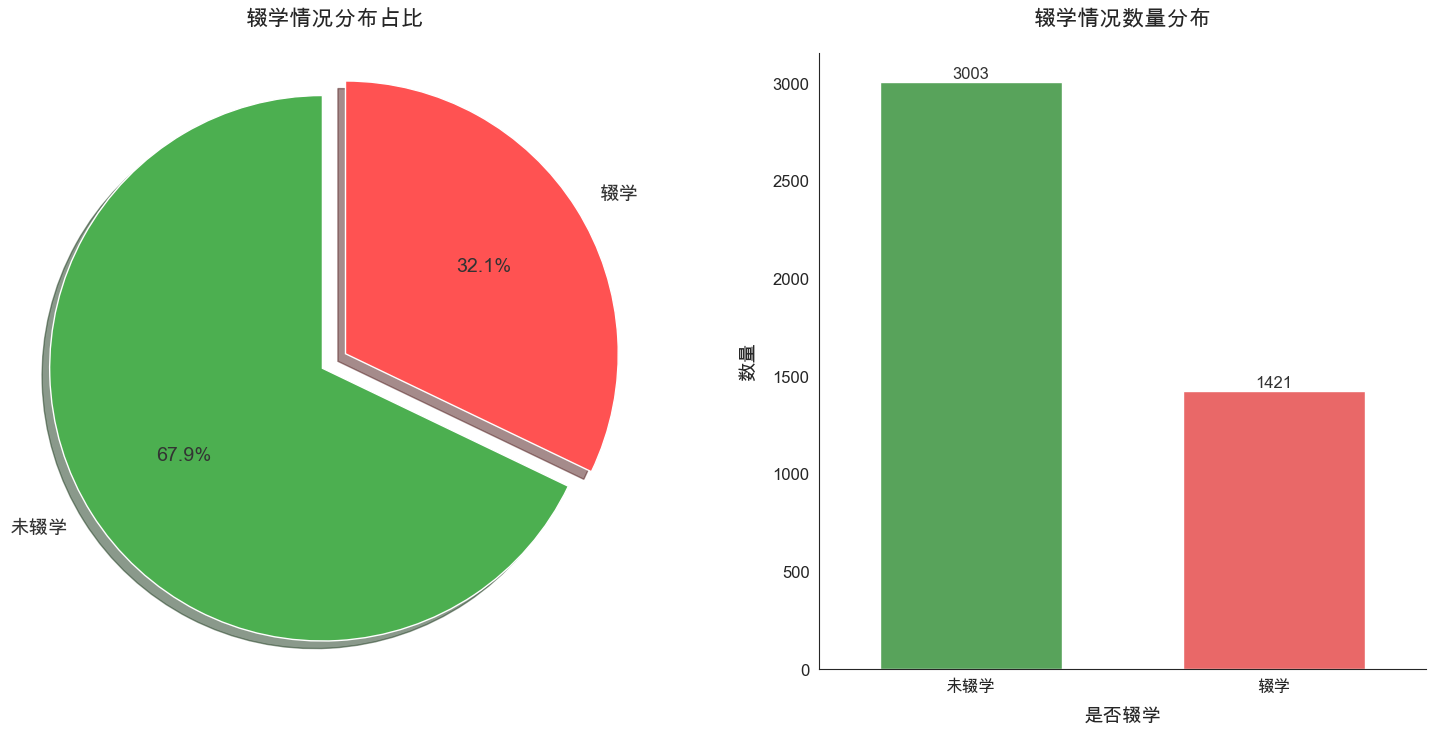

In [30]:
# 创建画布和子图，调整间距
f, ax = plt.subplots(1, 2, figsize=(18, 8))
plt.subplots_adjust(wspace=0.3)  # 调整子图间距

# 定义配色方案（柔和且对比明显）
# 0 (未辍学) 对应 绿色， 1 (辍学) 对应 红色
colors = ['#4CAF50', '#FF5252']

# 饼图优化
# 注意：value_counts() 默认按数量降序排列，通常 0 (未辍学) 更多，所以 colors[0] 对应 0
train_data['Target'].value_counts().plot.pie(
    explode=[0, 0.1],
    autopct='%1.1f%%',
    ax=ax[0],
    shadow=True,
    colors=colors,
    startangle=90,  # 旋转90度
    textprops={'fontsize': 14, 'color': '#333333'},  # 百分比文字样式
    labels=['未辍学', '辍学'] # 添加自定义标签让图例更清晰
)
ax[0].set_title('辍学情况分布占比', fontsize=16, pad=20, fontweight='bold')  # 标题样式优化
ax[0].set_ylabel('')  # 去除y轴标签
ax[0].axis('equal')  # 保证饼图是正圆形

# 柱状图优化
sns.countplot(
    x='Target',
    data=train_data,
    ax=ax[1],
    palette=colors,
    width=0.6  # 调整柱宽
)
ax[1].set_title('辍学情况数量分布', fontsize=16, pad=20, fontweight='bold')
ax[1].set_xlabel('是否辍学', fontsize=14, labelpad=10)  # x轴标签优化
ax[1].set_ylabel('数量', fontsize=14, labelpad=10)
ax[1].set_xticklabels(['未辍学', '辍学']) # 将 0/1 轴标签改为文字

# 为柱状图添加数值标签
for p in ax[1].patches:
    height = p.get_height()
    ax[1].text(
        p.get_x() + p.get_width() / 2.,  # x坐标
        height + 5,  # y坐标（在柱顶上方）
        f'{int(height)}',  # 显示的数值
        ha='center', va='bottom', fontsize=12, color='#333333'
    )

# 美化坐标轴刻度
ax[1].tick_params(axis='both', which='major', labelsize=12)

# 去除顶部和右侧边框
for spine in ax[1].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

plt.show()

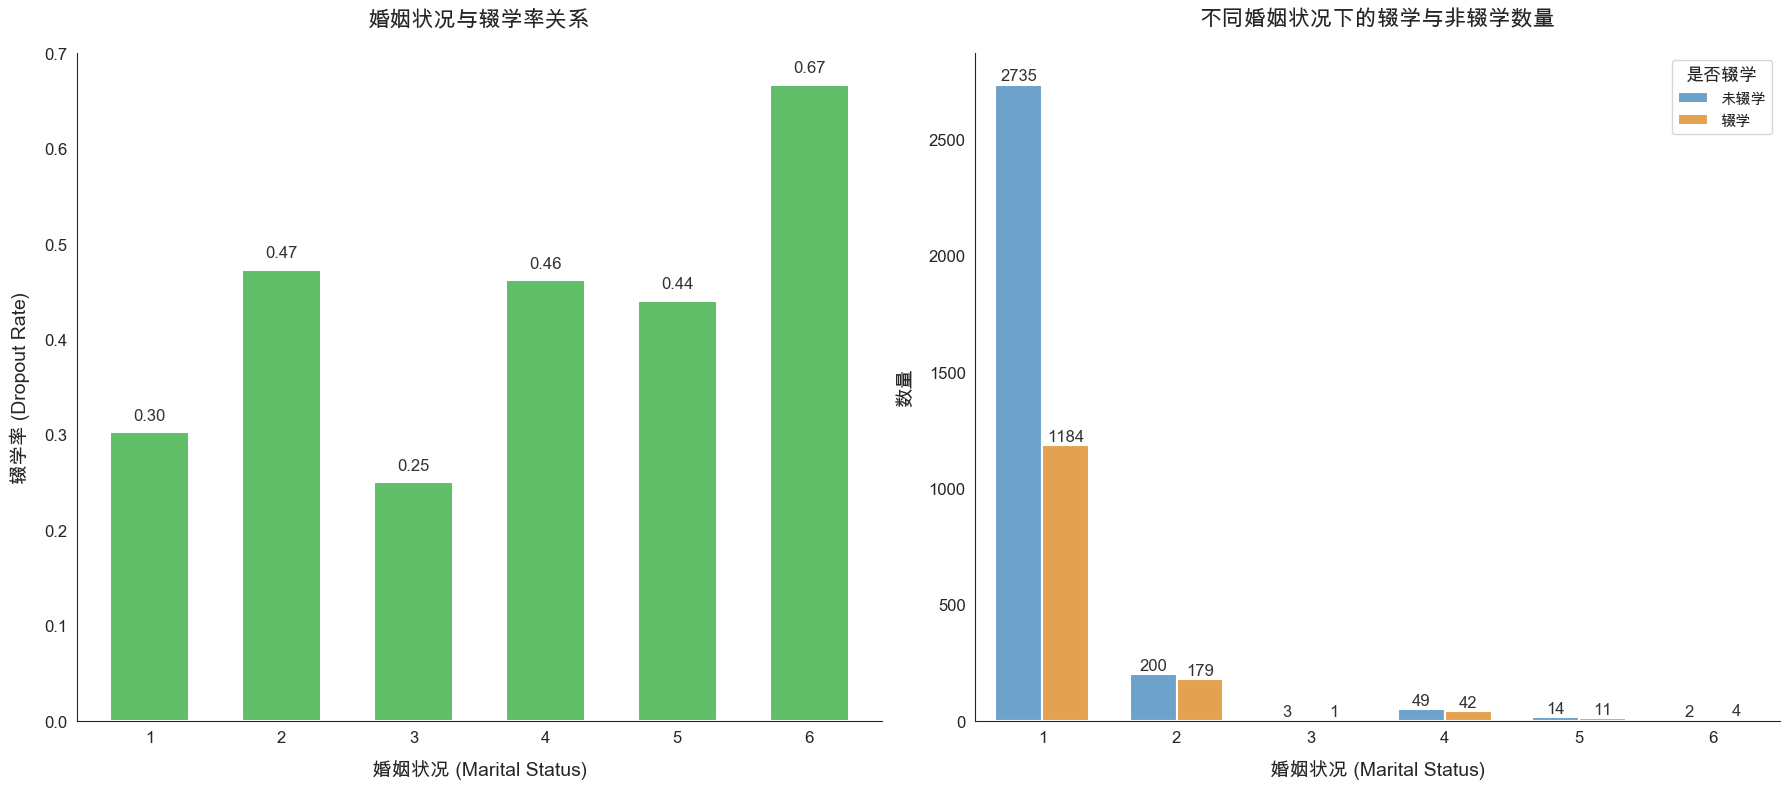

In [31]:
# 创建画布，调整子图间距
f, ax = plt.subplots(1, 2, figsize=(18, 8))
plt.subplots_adjust(wspace=0.25)  # 控制两图间距，避免拥挤

# 定义统一配色（柔和且专业）
bar_colors = ['#5DA5DA', '#FAA43A']  # 蓝色系（未辍学）和橙色系（辍学）
mean_color = '#60BD68'  # 均值柱状图用绿色，突出趋势

# 左侧：均值柱状图优化
# 计算不同婚姻状况下的辍学率均值
# 注意：Target为0/1变量，Mean即为辍学率
status_dropout_mean = train_data[['Marital status', 'Target']].groupby(['Marital status']).mean()

status_dropout_mean.plot.bar(
    ax=ax[0],
    color=mean_color,
    width=0.6,  # 适中的柱宽
    edgecolor='white',  # 白色边框增强立体感
    linewidth=1.5,
    legend=False # 不需要图例
)
ax[0].set_title('婚姻状况与辍学率关系', fontsize=16, pad=20, fontweight='bold')
ax[0].set_xlabel('婚姻状况 (Marital Status)', fontsize=14, labelpad=10)
ax[0].set_ylabel('辍学率 (Dropout Rate)', fontsize=14, labelpad=10)
ax[0].tick_params(axis='x', labelsize=12, rotation=0)  # 婚姻状况代码较短，水平显示即可
ax[0].tick_params(axis='y', labelsize=12)

# 为均值图添加数值标签（保留两位小数）
for p in ax[0].patches:
    ax[0].text(
        p.get_x() + p.get_width()/2, p.get_height() + 0.01,
        f'{p.get_height():.2f}',  # 显示辍学率数值
        ha='center', va='bottom', fontsize=12, color='#333333'
    )

# 去除左侧图顶部和右侧边框，更简洁
for spine in ax[0].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# 右侧：分组计数图优化
sns.countplot(
    x='Marital status',
    hue='Target',
    data=train_data,
    ax=ax[1],
    palette=bar_colors,
    width=0.7,
    edgecolor='white',
    linewidth=1.5
)
ax[1].set_title('不同婚姻状况下的辍学与非辍学数量', fontsize=16, pad=20, fontweight='bold')
ax[1].set_xlabel('婚姻状况 (Marital Status)', fontsize=14, labelpad=10)
ax[1].set_ylabel('数量', fontsize=14, labelpad=10)
ax[1].tick_params(axis='x', labelsize=12, rotation=0)
ax[1].tick_params(axis='y', labelsize=12)

# 为分组计数图添加数值标签
for p in ax[1].patches:
    height = p.get_height()
    if height > 0:  # 只显示有数值的标签
        ax[1].text(
            p.get_x() + p.get_width()/2, height + 5,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12, color='#333333'
        )

# 优化右侧图图例
# 修改图例标签为中文
handles, _ = ax[1].get_legend_handles_labels()
ax[1].legend(handles=handles, labels=['未辍学', '辍学'], title='是否辍学', title_fontsize=13, fontsize=11, loc='upper right')

# 去除右侧图顶部和右侧边框
for spine in ax[1].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# 整体布局调整
plt.tight_layout()
plt.show()

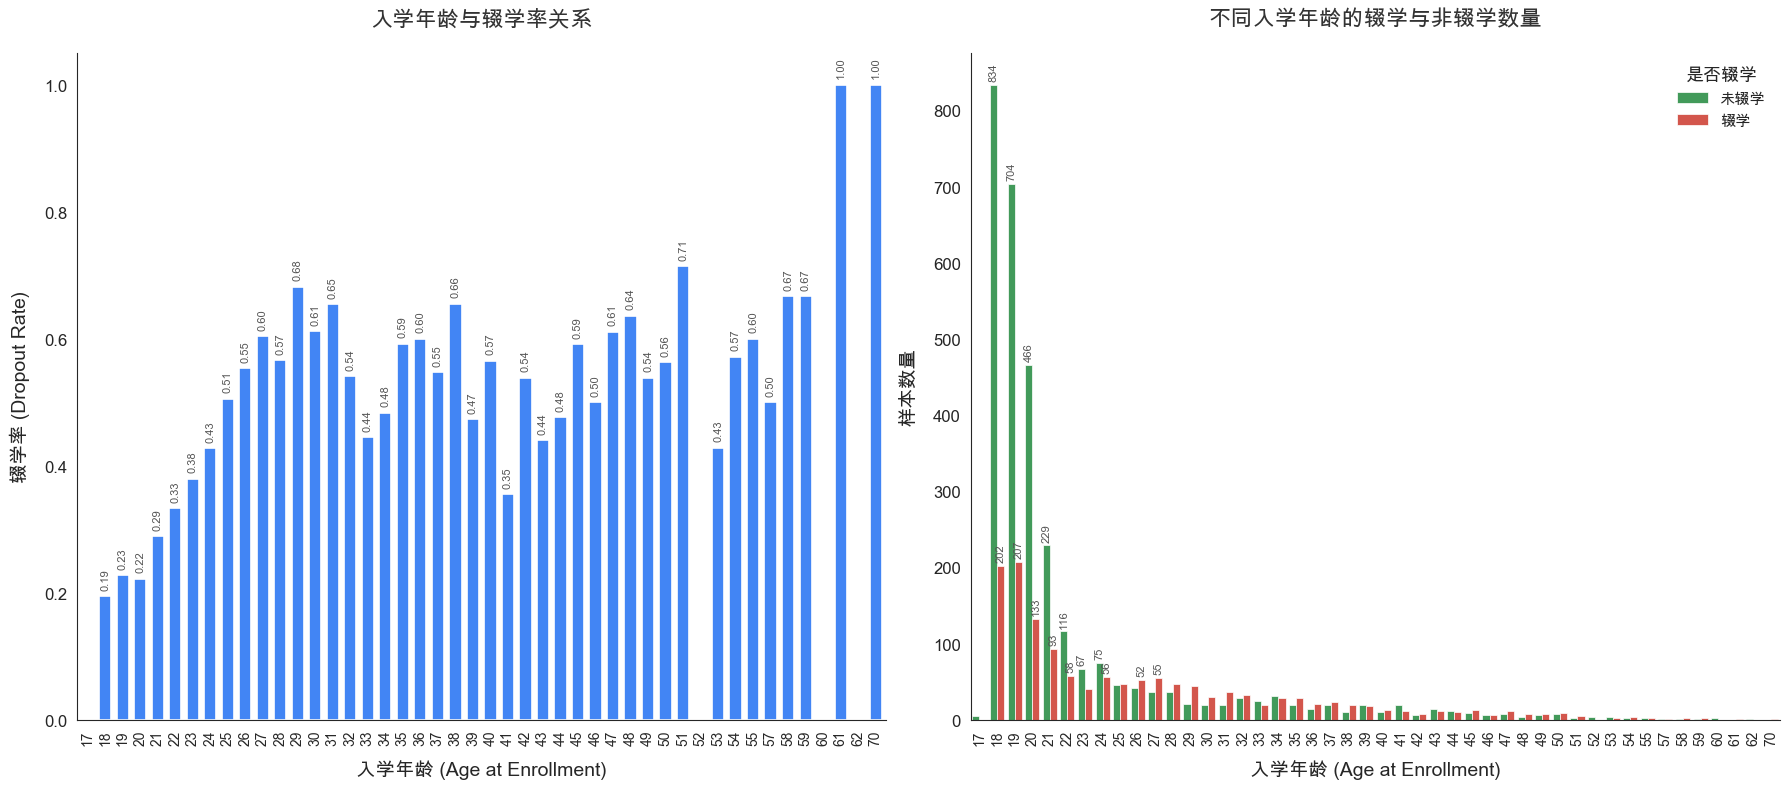

In [32]:
# 创建画布并调整布局
f, ax = plt.subplots(1, 2, figsize=(18, 8))
plt.subplots_adjust(wspace=0.25)  # 合理分配子图间距

# 定义专业配色（冷色调为主）
mean_color = '#4285F4'  # 左侧均值图用蓝色
count_colors = ['#34A853', '#EA4335']  # 右侧计数图用 绿(未辍学)/红(辍学)

# -----------------------------------------------------------
# 左侧：入学年龄与辍学率关系（均值图优化）
# -----------------------------------------------------------
# 计算每个年龄的辍学率均值
age_dropout_mean = train_data[['Age at enrollment', 'Target']].groupby(['Age at enrollment']).mean()

# 按年龄自然排序
age_dropout_mean = age_dropout_mean.sort_index()

age_dropout_mean.plot.bar(
    ax=ax[0],
    color=mean_color,
    width=0.7,
    edgecolor='white',  # 白色边框增强柱体立体感
    linewidth=1.2,
    legend=False
)

# 左侧图标题与标签优化
ax[0].set_title('入学年龄与辍学率关系', fontsize=16, pad=20, fontweight='bold', color='#333333')
ax[0].set_xlabel('入学年龄 (Age at Enrollment)', fontsize=14, labelpad=10)
ax[0].set_ylabel('辍学率 (Dropout Rate)', fontsize=14, labelpad=10)
ax[0].tick_params(axis='x', labelsize=10, rotation=90)  # 年龄较多，旋转90度更清晰
ax[0].tick_params(axis='y', labelsize=12)

# 添加辍学率数值标签
# 由于年龄柱子较多，我们只在每隔几个柱子或特定高低点显示数值，或者调整字体大小
# 这里为了保持整洁，仅对数值进行精简显示，或者您可以选择仅显示高于某个阈值的
for p in ax[0].patches:
    height = p.get_height()
    # 仅在柱子高度足够时显示，避免标签过于拥挤
    if height > 0: 
        ax[0].text(
            p.get_x() + p.get_width()/2, height + 0.01,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=8, color='#555555', rotation=90
        )

# 去除左侧图顶部和右侧边框
for spine in ax[0].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# -----------------------------------------------------------
# 右侧：不同入学年龄的辍学/非辍学数量分布（计数图优化）
# -----------------------------------------------------------
# 获取排序后的年龄列表，保证x轴顺序一致
sorted_ages = sorted(train_data['Age at enrollment'].unique())

sns.countplot(
    x='Age at enrollment',
    hue='Target',
    data=train_data,
    ax=ax[1],
    palette=count_colors,
    width=0.8, # 稍微调宽一点
    edgecolor='white',
    linewidth=0.5,
    order=sorted_ages  # 按年龄从小到大排序
)

# 右侧图标题与标签优化
ax[1].set_title('不同入学年龄的辍学与非辍学数量', fontsize=16, pad=20, fontweight='bold', color='#333333')
ax[1].set_xlabel('入学年龄 (Age at Enrollment)', fontsize=14, labelpad=10)
ax[1].set_ylabel('样本数量', fontsize=14, labelpad=10)
ax[1].tick_params(axis='x', labelsize=10, rotation=90)
ax[1].tick_params(axis='y', labelsize=12)

# 添加数量标签（仅显示较高的柱子，防止重叠）
# 针对这种密集柱状图，通常可以省略具体数值或仅标注极值
# 这里我们保留代码但设置字体更小
for p in ax[1].patches:
    height = p.get_height()
    if height > 50: # 仅显示数量大于50的标签，保持画面整洁
        ax[1].text(
            p.get_x() + p.get_width()/2, height + 5,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=8, color='#555555', rotation=90
        )

# 优化图例
handles, _ = ax[1].get_legend_handles_labels()
ax[1].legend(
    handles=handles,
    title='是否辍学', 
    labels=['未辍学', '辍学'],
    title_fontsize=13, 
    fontsize=11, 
    loc='upper right',
    frameon=False
)

# 去除右侧图顶部和右侧边框
for spine in ax[1].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# 整体布局调整
plt.tight_layout()
plt.show()

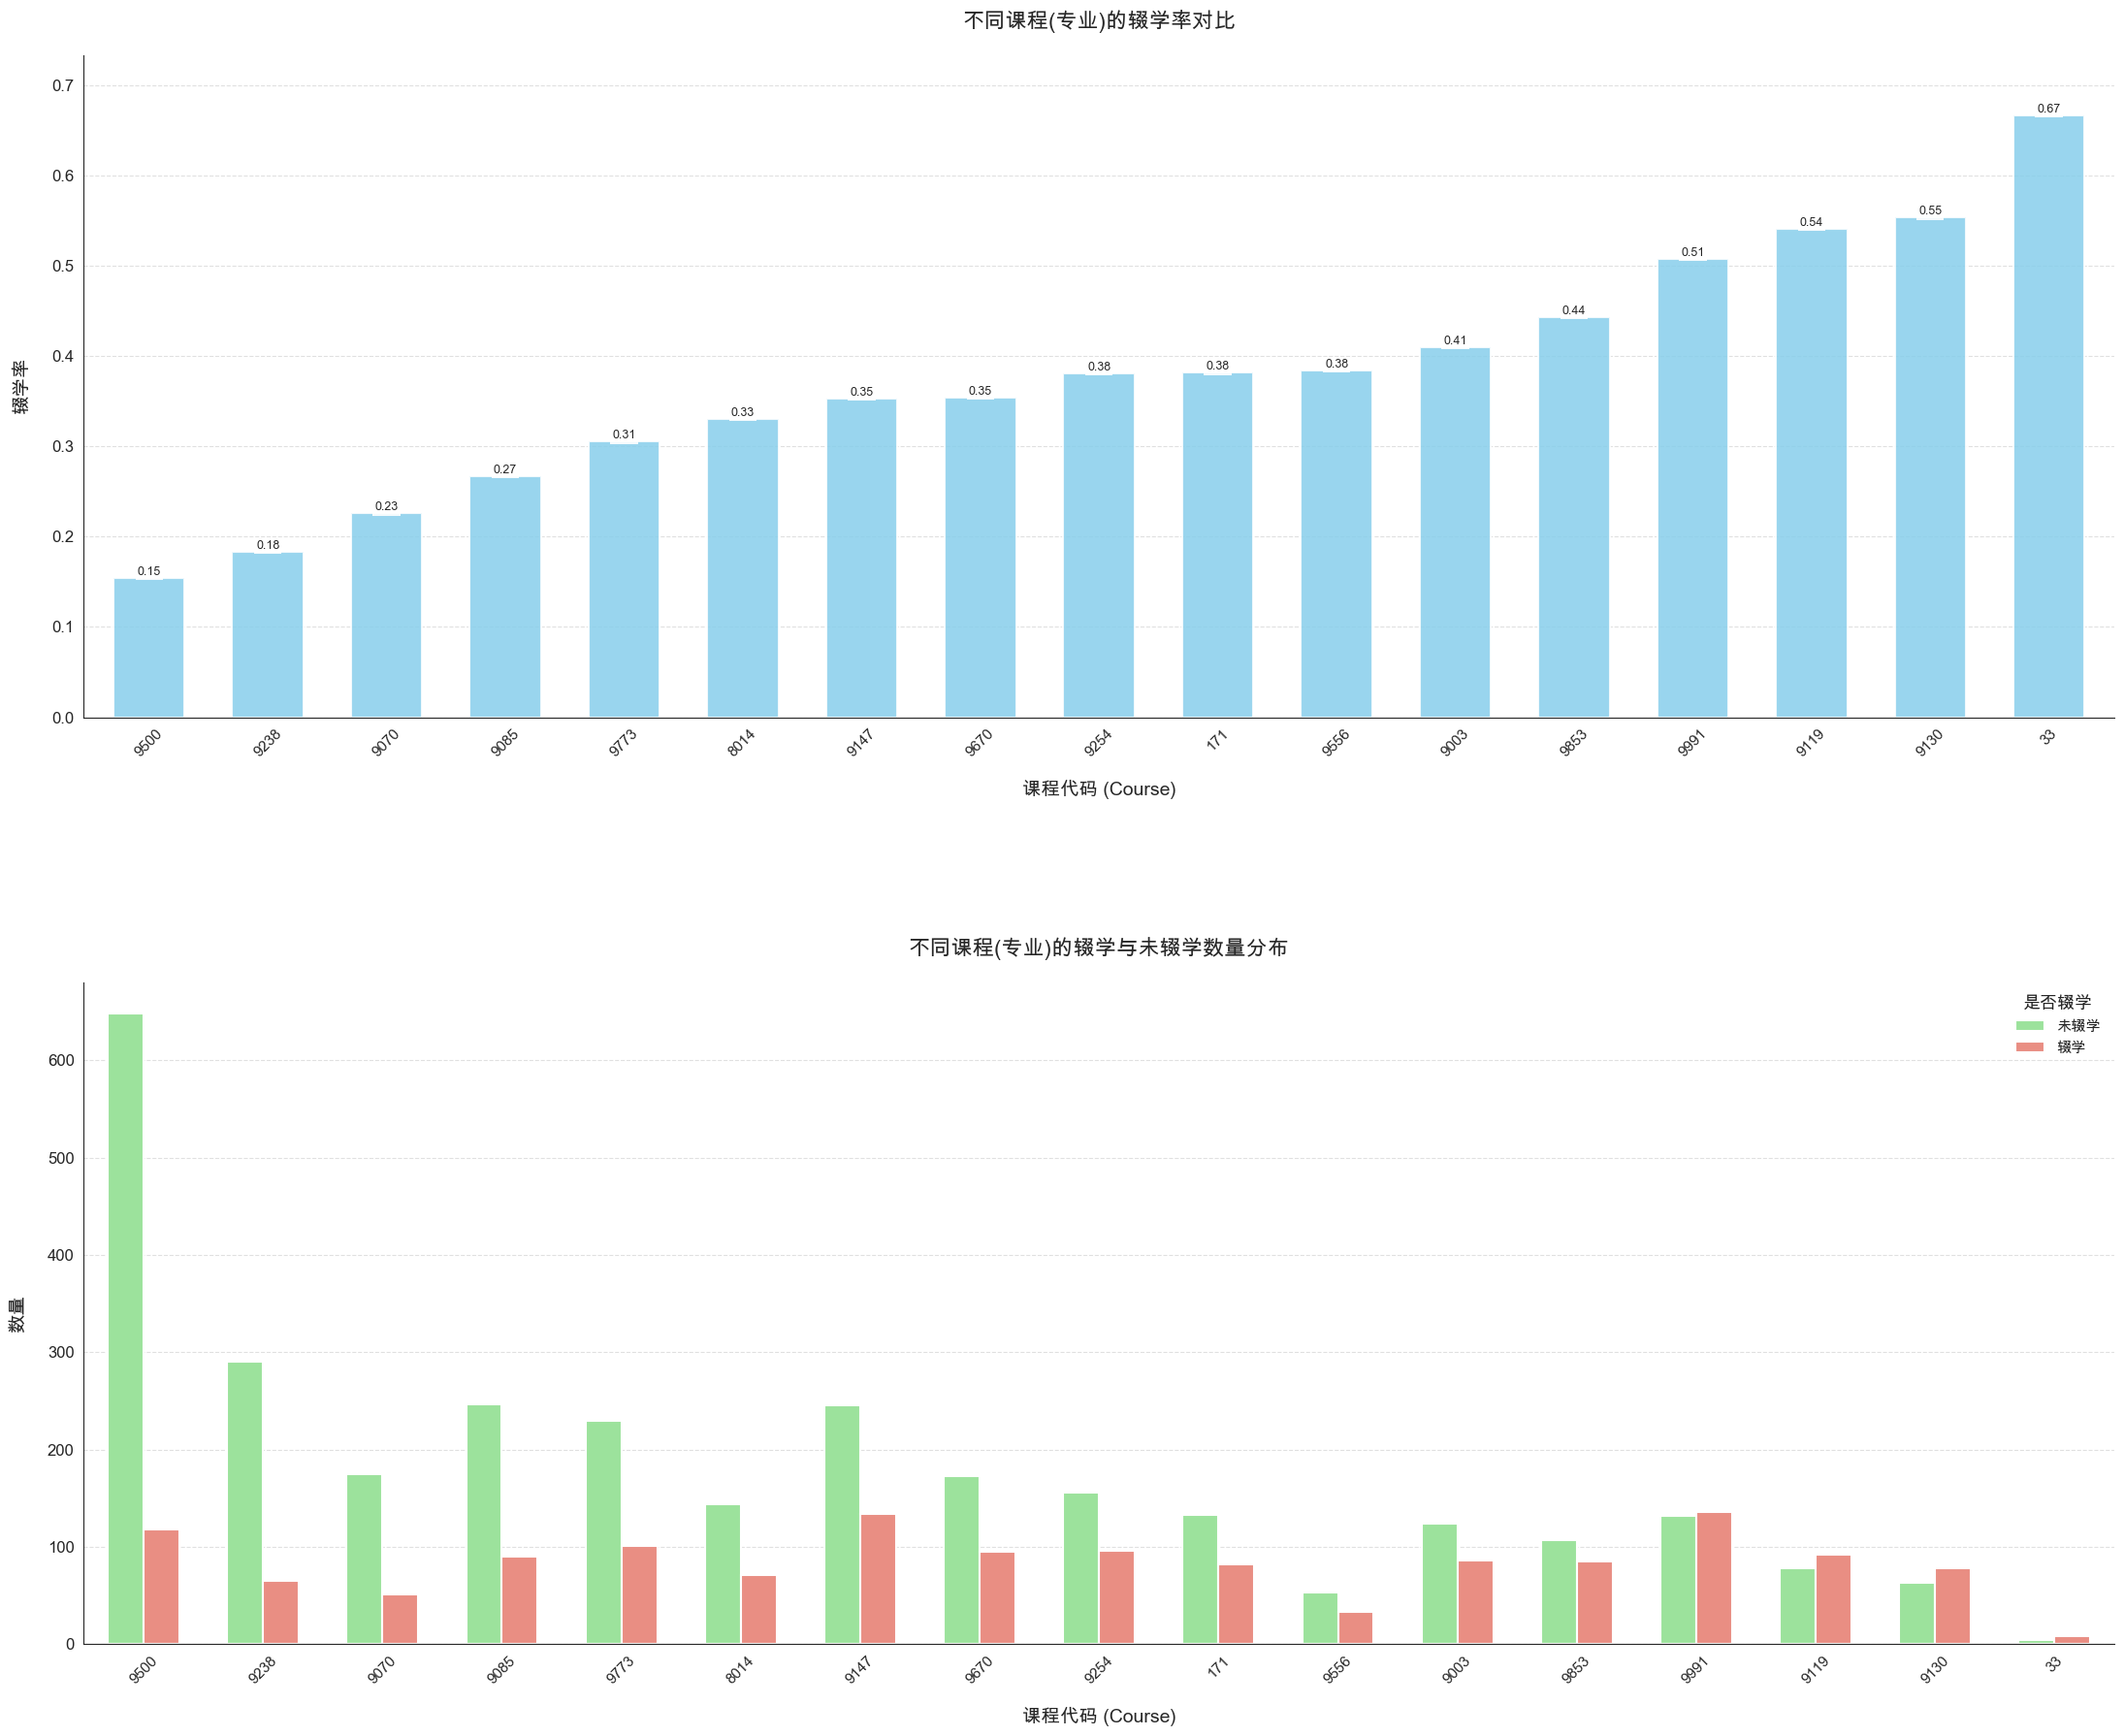

In [33]:
# 调整画布尺寸，给17个类别足够空间 (Course有17类)
f, ax = plt.subplots(2, 1, figsize=(22, 18))  # 适当加宽画布，避免标签重叠

# 数据预处理：按辍学率排序
# 将 'Course' 转换为字符串，以免被当做数值处理，且方便显示
train_data['Course'] = train_data['Course'].astype(str)
# 计算每个课程的辍学率均值
course_dropout = train_data[['Course', 'Target']].groupby('Course').mean()
# 按辍学率从小到大排序
course_dropout = course_dropout.sort_values('Target')

# -----------------------------------------------------------
# 第一个子图：辍学率柱状图（所有柱子显示占比）
# -----------------------------------------------------------
course_dropout['Target'].plot.bar(
    ax=ax[0], 
    width=0.6, 
    edgecolor='white', 
    linewidth=1.5, 
    alpha=0.85, 
    color='skyblue'
)

# 美化第一个子图
ax[0].set_title('不同课程(专业)的辍学率对比', fontsize=16, pad=20, fontweight='bold')
ax[0].set_xlabel('课程代码 (Course)', fontsize=14, labelpad=15)
ax[0].set_ylabel('辍学率', fontsize=14, labelpad=15)
ax[0].grid(axis='y', linestyle='--', alpha=0.6, color='#cccccc')
ax[0].tick_params(axis='x', rotation=45, labelsize=11)  # 标签旋转45度，平衡可读性和空间
ax[0].tick_params(axis='y', labelsize=12)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].set_ylim(0, course_dropout['Target'].max() * 1.1)  # 预留标签空间

# 为所有柱子添加占比标签（优化布局避免拥挤）
for p in ax[0].patches:
    height = p.get_height()
    ax[0].annotate(
        f'{height:.2f}',  # 保留两位小数
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',  # 水平居中，垂直靠下
        fontsize=9,  # 缩小字体避免拥挤
        rotation=0,  # 标签水平显示，更易读
        bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.9)  # 白色背景突出标签
    )

# -----------------------------------------------------------
# 第二个子图：辍学状态计数图（保持排序一致）
# -----------------------------------------------------------
order = course_dropout.index  # 使用上图排序好的索引
sns.countplot(
    x='Course', hue='Target', data=train_data, ax=ax[1],
    order=order, width=0.6, edgecolor='white', linewidth=1.5,
    palette=['lightgreen', 'salmon']  # 绿(未辍学) / 红(辍学)
)

# 美化第二个子图
ax[1].set_title('不同课程(专业)的辍学与未辍学数量分布', fontsize=16, pad=20, fontweight='bold')
ax[1].set_xlabel('课程代码 (Course)', fontsize=14, labelpad=15)
ax[1].set_ylabel('数量', fontsize=14, labelpad=15)
ax[1].grid(axis='y', linestyle='--', alpha=0.6, color='#cccccc')
ax[1].tick_params(axis='x', rotation=45, labelsize=11)
ax[1].tick_params(axis='y', labelsize=12)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

# 更新图例标签为中文
handles, _ = ax[1].get_legend_handles_labels()
ax[1].legend(handles=handles, labels=['未辍学', '辍学'], title='是否辍学', title_fontsize=13, fontsize=11, loc='upper right', frameon=False)

# 调整整体布局
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)  # 上下子图间距
plt.show()

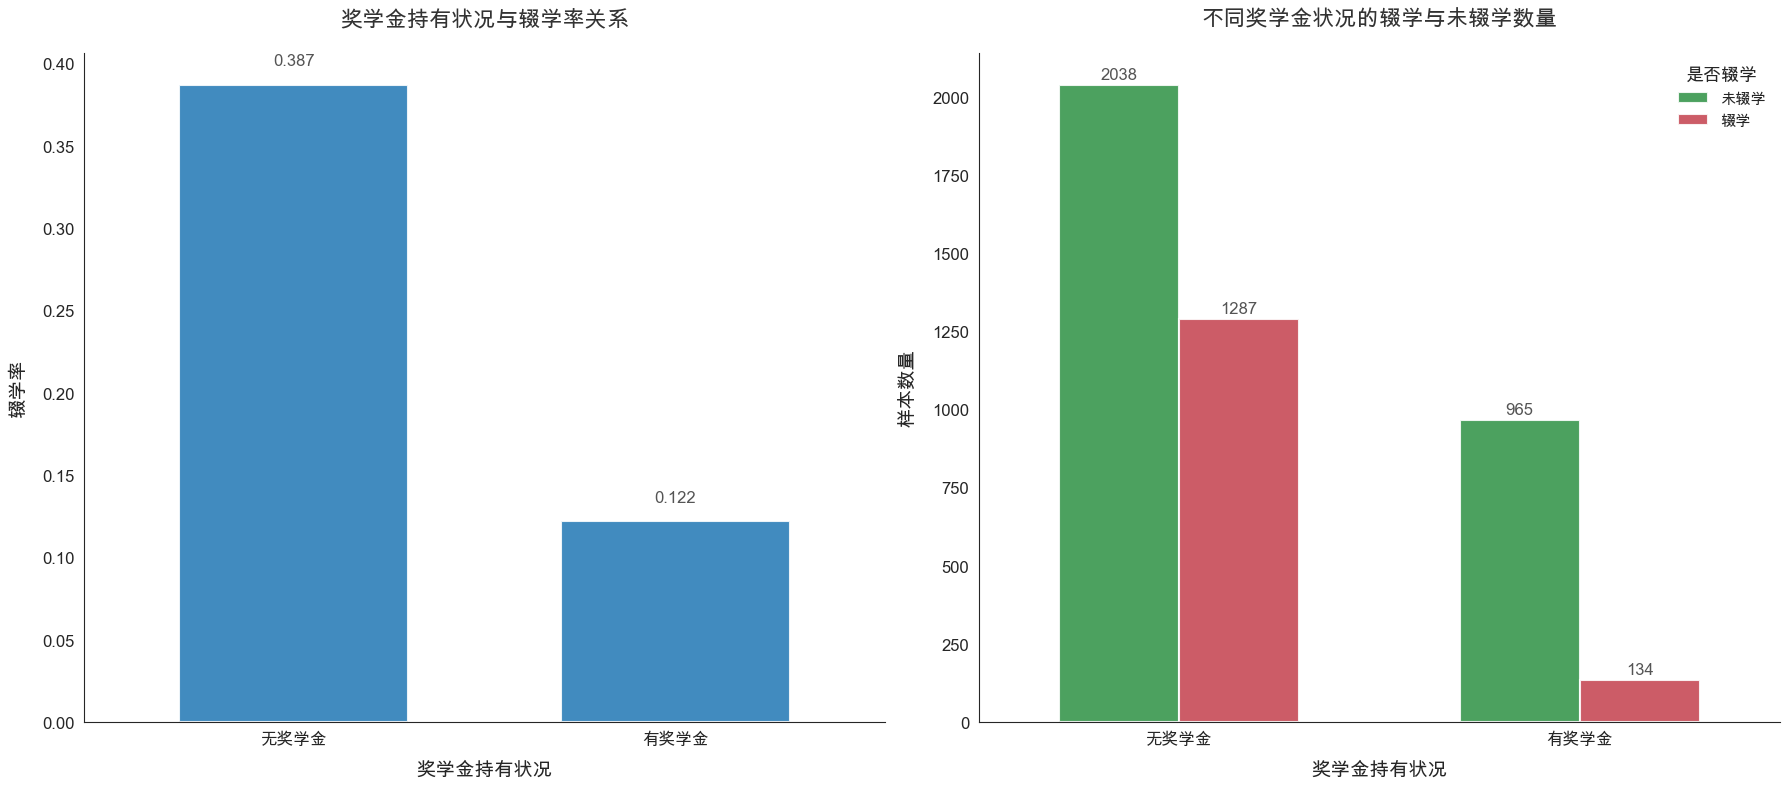

In [34]:
# 为了让图表标签更直观，我们将数值映射为中文文本
# 假设 0 代表无奖学金，1 代表有奖学金 (根据一般数据集定义)
train_data['Scholarship Status'] = train_data['Scholarship holder'].map({0: '无奖学金', 1: '有奖学金'})

# 创建画布并调整布局（适当加宽间距）
f, ax = plt.subplots(1, 2, figsize=(18, 8))
plt.subplots_adjust(wspace=0.3)  # 增加子图间距

# 定义专业配色
mean_color = '#2C7FB8'  # 左侧均值图用深蓝色
count_colors = ['#28A745', '#DC3545']  # 右侧计数图用 绿(未辍学)/红(辍学)

# -----------------------------------------------------------
# 左侧：奖学金持有状况与辍学率关系（均值图优化）
# -----------------------------------------------------------
# 计算均值
scholarship_mean = train_data[['Scholarship Status', 'Target']].groupby(['Scholarship Status']).mean()

# 按逻辑排序（无 -> 有）
sorted_status = ['无奖学金', '有奖学金']
scholarship_mean = scholarship_mean.reindex(sorted_status)

scholarship_mean.plot.bar(
    ax=ax[0],
    color=mean_color,
    width=0.6,  # 适中柱宽
    edgecolor='white',
    linewidth=1.5,
    alpha=0.9,
    legend=False
)

# 左侧标题与标签优化
ax[0].set_title('奖学金持有状况与辍学率关系', fontsize=16, pad=20, fontweight='bold', color='#333333')
ax[0].set_xlabel('奖学金持有状况', fontsize=14, labelpad=10)
ax[0].set_ylabel('辍学率', fontsize=14, labelpad=10)
ax[0].tick_params(axis='x', labelsize=12, rotation=0)
ax[0].tick_params(axis='y', labelsize=12)

# 添加辍学率数值标签
for p in ax[0].patches:
    ax[0].text(
        p.get_x() + p.get_width()/2, p.get_height() + 0.01,
        f'{p.get_height():.3f}',
        ha='center', va='bottom', fontsize=12, color='#555555'
    )

# 去除左侧图顶部和右侧边框
for spine in ax[0].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# -----------------------------------------------------------
# 右侧：不同奖学金状况的辍学/非辍学数量分布（计数图优化）
# -----------------------------------------------------------
sns.countplot(
    x='Scholarship Status',
    hue='Target',
    data=train_data,
    ax=ax[1],
    palette=count_colors,
    width=0.6,
    edgecolor='white',
    linewidth=1.5,
    alpha=0.9,
    order=sorted_status  # 保持一致顺序
)

# 右侧标题与标签优化
ax[1].set_title('不同奖学金状况的辍学与未辍学数量', fontsize=16, pad=20, fontweight='bold', color='#333333')
ax[1].set_xlabel('奖学金持有状况', fontsize=14, labelpad=10)
ax[1].set_ylabel('样本数量', fontsize=14, labelpad=10)
ax[1].tick_params(axis='x', labelsize=12, rotation=0)
ax[1].tick_params(axis='y', labelsize=12)

# 添加数量标签
for p in ax[1].patches:
    height = p.get_height()
    # 稍微调整标签位置，避免贴得太近
    if height > 0:
        ax[1].text(
            p.get_x() + p.get_width()/2, height + 10,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12, color='#555555'
        )

# 优化图例
handles, _ = ax[1].get_legend_handles_labels()
ax[1].legend(
    handles=handles,
    title='是否辍学',
    labels=['未辍学', '辍学'],
    title_fontsize=13,
    fontsize=11,
    loc='upper right',
    frameon=False
)

# 去除右侧图顶部和右侧边框
for spine in ax[1].spines.values():
    if spine.spine_type in ['top', 'right']:
        spine.set_visible(False)

# 整体布局调整
plt.tight_layout()
plt.show()

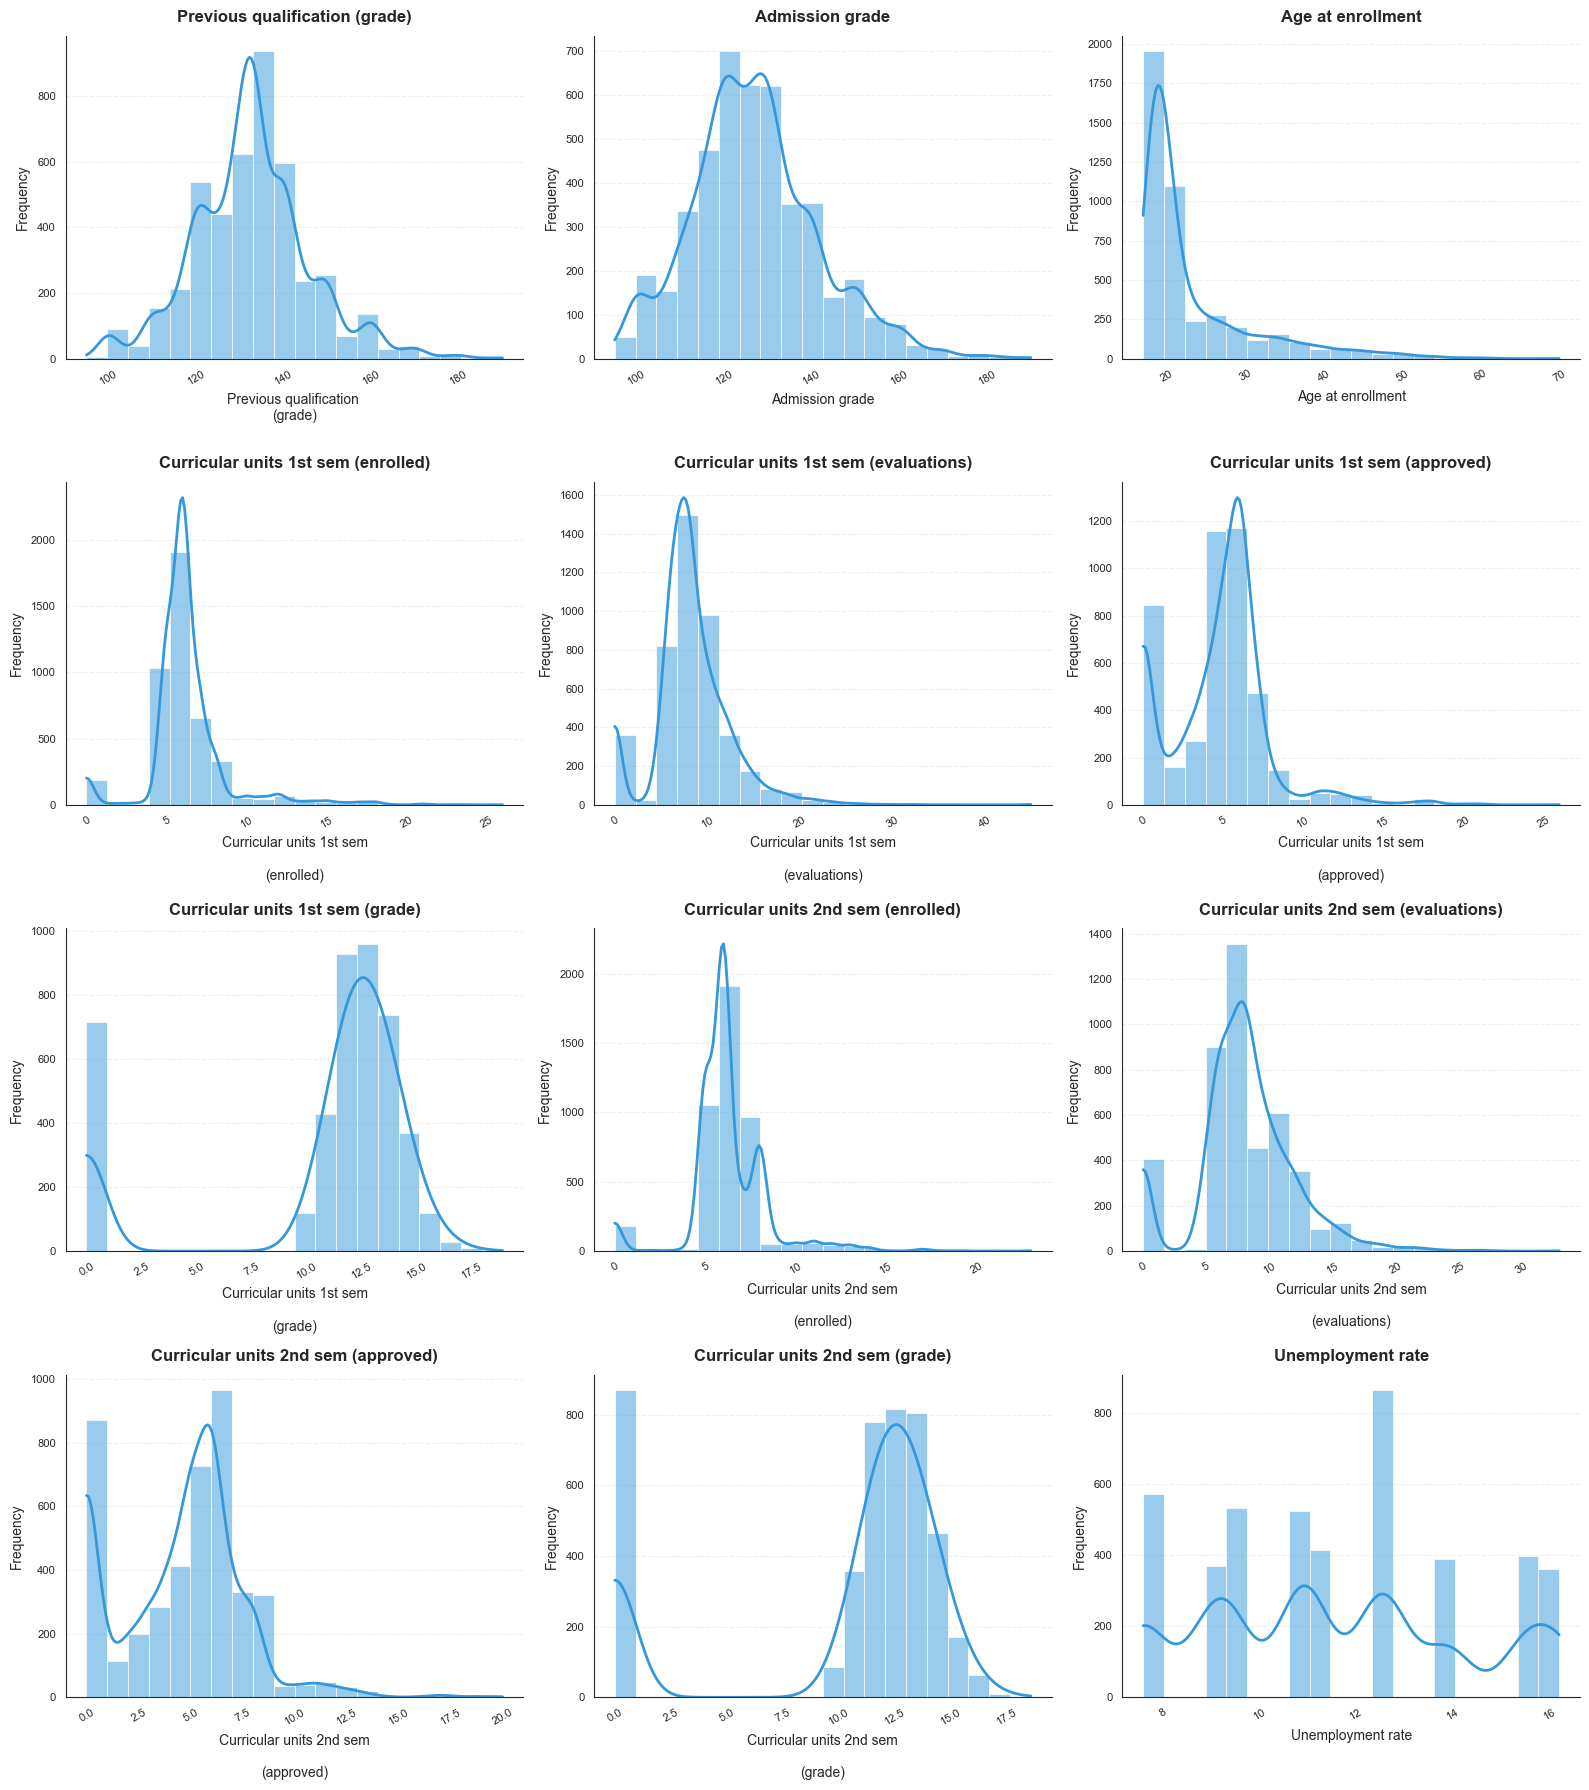

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 确保数据已加载
# train_data = pd.read_csv('train.csv')

sns.set_style("white")
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8

# 选择12个适合查看分布的数值型特征
NUM_FEATURE_NAMES = [
    'Previous qualification (grade)',   # 入学前成绩
    'Admission grade',                  # 入学考试成绩
    'Age at enrollment',                # 入学年龄
    'Curricular units 1st sem (enrolled)',    # 第一学期注册课程数
    'Curricular units 1st sem (evaluations)', # 第一学期评估次数
    'Curricular units 1st sem (approved)',    # 第一学期通过课程数
    'Curricular units 1st sem (grade)',       # 第一学期平均成绩
    'Curricular units 2nd sem (enrolled)',    # 第二学期注册课程数
    'Curricular units 2nd sem (evaluations)', # 第二学期评估次数
    'Curricular units 2nd sem (approved)',    # 第二学期通过课程数
    'Curricular units 2nd sem (grade)',       # 第二学期平均成绩
    'Unemployment rate'                 # 失业率
]

# 计算子图布局（4行3列）
n_rows = 4
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 18))
axes = axes.flatten()

for i, feature in enumerate(NUM_FEATURE_NAMES):
    ax = axes[i]
    
    # 修正：将kde的颜色参数移至line_kws
    sns.histplot(
        data=train_data,  # 使用当前的 train_data 数据集
        x=feature, 
        bins=20, 
        kde=True,
        ax=ax,
        color='#3498db',  # 直方图颜色 (蓝色)
        edgecolor='white',
        linewidth=0.5,
        line_kws={  # 核密度曲线的样式参数
            'color': '#e74c3c',  # 核密度曲线颜色 (红色)
            'linewidth': 2
        }
    )
    
    # 设置标题和标签
    ax.set_title(f'{feature}', pad=10, fontweight='bold')
    # 稍微调整长标签的换行，使其更美观
    ax.set_xlabel(feature.replace('(', '\n(').replace('sem ', 'sem\n'), labelpad=5)
    ax.set_ylabel('Frequency', labelpad=5)
    
    # 美化坐标轴
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=30)
    
    # 添加网格线
    ax.yaxis.grid(True, linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)

# 调整布局
plt.tight_layout()
plt.show()

# <a id='toc5_'></a>[工具函数](#toc0_)

In [36]:
def f1_best_threshold(y_true, y_prob):
    """返回最大化 F1 的阈值与对应 F1"""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1s = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1s)
    return thresholds[best_idx], f1s[best_idx]


# <a id='toc6_'></a>[数据预处理](#toc0_)


功能：处理数据中的缺失值和异常值，同时记录异常/缺失标记，为建模做准备

In [37]:
import pandas as pd
import numpy as np
import re

class DataPreprocessing:
    def __init__(self):
        # 存储数值型特征的中位数
        self.medians = None
        # 存储特征的众数
        self.modes = None
        # 存储清洗后的列名映射，保证训练和预测时列名一致
        self.clean_columns_map = {}

    def _clean_col_name(self, col_name):
        """
        清洗列名以适配XGBoost：
        1. 去除首尾空格
        2. 替换空格、斜杠、制表符为下划线
        3. 移除括号、引号等特殊字符
        """
        if not isinstance(col_name, str):
            return str(col_name)
        
        # 替换分隔符
        new_name = col_name.strip()
        new_name = re.sub(r'[\s/\t]+', '_', new_name)
        # 移除特殊字符 (保留字母、数字、下划线)
        new_name = re.sub(r'[^\w]', '', new_name)
        return new_name

    def fit(self, X):
        """从训练数据中学习统计特征"""
        # 1. 先清洗列名，确保统计指标对应的键名是清洗后的
        X = X.copy()
        X.columns = [self._clean_col_name(c) for c in X.columns]
        
        # 2. 计算中位数和众数
        self.medians = X.median(numeric_only=True)
        # 对于众数，如果存在多个，取第一个；且需确保包含非数值列（如果存在）
        self.modes = X.mode().iloc[0]
        
        return self

    def transform(self, X):
        """对数据进行清洗转换"""
        X = X.copy()
        
        # --------------------------
        # 1. 列名标准化（XGBoost 必要步骤）
        # --------------------------
        # 记录原始列名到清洗后列名的映射（便于排查问题）
        old_cols = X.columns
        new_cols = [self._clean_col_name(c) for c in old_cols]
        X.columns = new_cols
        
        # --------------------------
        # 2. 通用缺失值处理机制
        # --------------------------
        # 找出当前数据中含有缺失值的列
        cols_with_nan = X.columns[X.isna().any()].tolist()
        
        for col in cols_with_nan:
            # A. 添加缺失值标记列 (Is_NaN)
            # 这种特征对XGBoost很有用，能显式告诉模型这里原本是缺失的
            X[f'{col}_NaN'] = X[col].isna().astype(int)
            
            # B. 填充缺失值
            if col in self.medians:
                # 数值型用中位数填充
                fill_val = self.medians[col]
                X[col] = X[col].fillna(fill_val)
            elif col in self.modes:
                # 类别型用众数填充
                fill_val = self.modes[col]
                X[col] = X[col].fillna(fill_val)
            else:
                # 如果fit时没见过这个列（罕见情况），用0或空字符串兜底
                fill_val = 0 if pd.api.types.is_numeric_dtype(X[col]) else "Unknown"
                X[col] = X[col].fillna(fill_val)

        # --------------------------
        # 3. 数据类型优化 (可选)
        # --------------------------
        # 将 object 类型的类别变量转换为 category 类型，
        # XGBoost (enable_categorical=True) 可以直接处理
        for col in X.select_dtypes(include=['object']).columns:
             X[col] = X[col].astype('category')

        return X

# <a id='toc7_'></a>[特征工程](#toc0_)

1. **类别特征编码处理**  
   对贷款期限（Term）二值化、工作年限（Years in current job）有序编码、住房所有权（Home Ownership）独热编码，同时对贷款用途（Purpose）等做频数编码，将非数值类别特征转化为模型可使用的格式。

2. **数值特征优化转换**  
   按标准区间对信用评分（Credit Score）分箱并填充缺失值，对年收入、贷款金额等数值特征做对数变换，缓解数据偏度，提升数值特征对模型的适配性。

3. **关键新特征构建**  
   计算债务比率、信贷利用率等财务比例特征，生成“贷款用途-期限”类别交互特征，挖掘数据中隐藏的指标关联与组合效应，丰富特征维度。

4. **数据安全与完整性保障**  
   复制原始数据避免修改，通过条件判断确保特征存在再处理，将计算中出现的无穷值替换为缺失值，保障特征工程过程中数据的安全性与有效性。

In [38]:
import pandas as pd
import numpy as np

class FeatureGenerator:
    """
    特征生成器类：专为学生辍学/学业成功预测设计
    用于生成具有业务解释性的衍生特征
    """
    
    def transform(self, X):
        """
        对输入数据进行特征转换处理
        
        参数:
            X: pandas.DataFrame，原始输入数据
            
        返回:
            pandas.DataFrame，处理后的特征数据
        """
        # 复制数据，避免修改原始DataFrame
        X = X.copy()
        
        # 为了兼容性，先标准化列名（去除空格、括号等，与XGBoost兼容）
        # 建立列名映射字典，方便后续操作
        col_map = {c: c.strip().replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '').replace("'", "") 
                   for c in X.columns}
        X.rename(columns=col_map, inplace=True)
        
        # 定义基础列名变量（使用清洗后的列名）
        c_grade_1 = 'Curricular_units_1st_sem_grade'
        c_grade_2 = 'Curricular_units_2nd_sem_grade'
        c_approved_1 = 'Curricular_units_1st_sem_approved'
        c_approved_2 = 'Curricular_units_2nd_sem_approved'
        c_enrolled_1 = 'Curricular_units_1st_sem_enrolled'
        c_enrolled_2 = 'Curricular_units_2nd_sem_enrolled'
        c_evals_1 = 'Curricular_units_1st_sem_evaluations'
        c_evals_2 = 'Curricular_units_2nd_sem_evaluations'
        
        # -------------------------------------------------------
        # 1. 学业表现趋势特征 (Academic Performance Trends)
        # -------------------------------------------------------
        # 成绩变化：第二学期成绩 - 第一学期成绩
        # 解释：正值表示进步，负值表示退步，这是预测辍学的重要动态指标
        X['Grade_Improvement'] = X[c_grade_2] - X[c_grade_1]
        
        # 成绩波动比率：第二学期成绩 / (第一学期成绩 + 0.1)
        X['Grade_Ratio'] = X[c_grade_2] / (X[c_grade_1] + 0.1)

        # -------------------------------------------------------
        # 2. 课程通过率特征 (Approval Rates)
        # -------------------------------------------------------
        # 第一学期通过率：通过科目数 / 注册科目数 (避免除零)
        X['Approval_Rate_1st'] = X[c_approved_1] / (X[c_enrolled_1] + 1)
        
        # 第二学期通过率
        X['Approval_Rate_2nd'] = X[c_approved_2] / (X[c_enrolled_2] + 1)
        
        # 全年通过率变化：第二学期通过率 - 第一学期通过率
        X['Approval_Rate_Change'] = X['Approval_Rate_2nd'] - X['Approval_Rate_1st']

        # -------------------------------------------------------
        # 3. 学习压力与负荷 (Study Load & Pressure)
        # -------------------------------------------------------
        # 评估密度：评估次数 / 注册课程数
        # 解释：如果不通过的课程多但评估次数极高，可能代表学生尝试了但失败，或者课程本身很难
        X['Evaluation_Density_1st'] = X[c_evals_1] / (X[c_enrolled_1] + 1)
        X['Evaluation_Density_2nd'] = X[c_evals_2] / (X[c_enrolled_2] + 1)
        
        # 总挂科数：(注册1 + 注册2) - (通过1 + 通过2)
        X['Total_Failed_Units'] = (X[c_enrolled_1] + X[c_enrolled_2]) - (X[c_approved_1] + X[c_approved_2])

        # -------------------------------------------------------
        # 4. 经济与社会压力 (Socio-Economic Pressure)
        # -------------------------------------------------------
        # 宏观经济痛苦指数 (Misery Index 简化版)：失业率 + 通胀率
        # 解释：外部经济环境越差，学生因经济原因辍学的风险可能越高
        if 'Unemployment_rate' in X.columns and 'Inflation_rate' in X.columns:
            X['Economic_Misery_Index'] = X['Unemployment_rate'] + X['Inflation_rate']
            
        # GDP与失业率交互
        if 'GDP' in X.columns and 'Unemployment_rate' in X.columns:
            X['GDP_Unemployment_Interaction'] = X['GDP'] * X['Unemployment_rate']

        # -------------------------------------------------------
        # 5. 财务支持状况 (Financial Support Status)
        # -------------------------------------------------------
        # 奖学金且无欠费：Scholarship_holder * Tuition_fees_up_to_date
        # 解释：这是一个强正面信号，代表资金充足且合规
        if 'Scholarship_holder' in X.columns and 'Tuition_fees_up_to_date' in X.columns:
            X['Secure_Financial_Status'] = X['Scholarship_holder'] * X['Tuition_fees_up_to_date']
            
        # 欠费且无奖学金 (高风险标志)
        if 'Scholarship_holder' in X.columns and 'Debtor' in X.columns:
            X['High_Financial_Risk'] = X['Debtor'] * (1 - X['Scholarship_holder'])

        # -------------------------------------------------------
        # 6. 年龄分段 (Age Binning)
        # -------------------------------------------------------
        # 将入学年龄分箱，区分“适龄学生”与“大龄学生”
        # 17-21(正常), 22-26(稍晚), 27-35, 36+
        if 'Age_at_enrollment' in X.columns:
            X['Age_Bin'] = pd.cut(X['Age_at_enrollment'], 
                                  bins=[0, 21, 26, 35, 100], 
                                  labels=[0, 1, 2, 3]).astype(float) # 转换为数值以便模型处理

        # -------------------------------------------------------
        # 7. 类别特征频率编码 (Frequency Encoding)
        # -------------------------------------------------------
        # 针对高基数类别特征（如 Course, Application_mode），用出现频率代替类别ID
        # 这能反映该专业/入学方式的热门程度
        for col in ['Course', 'Application_mode', 'Mothers_occupation', 'Fathers_occupation']:
            if col in X.columns:
                freq = X[col].value_counts(normalize=True)
                X[f'{col}_Freq'] = X[col].map(freq)

        # -------------------------------------------------------
        # 8. 清理无穷值与缺失值
        # -------------------------------------------------------
        # 衍生特征计算中可能产生 inf (除零)，将其替换为 NaN 或 0
        X.replace([np.inf, -np.inf], 0, inplace=True)
        X.fillna(0, inplace=True)
        
        return X

1. 从训练数据中分离目标变量（转为整数）和特征数据，复制测试数据。
2. 用训练特征拟合预处理模型，再分别对训练和测试特征做预处理。
3. 通过特征生成器对预处理后的训练、测试特征进行特征工程，确保处理一致性，为建模做准备。

In [39]:
# 定义目标变量列名
target_col = "Target"

# 从训练数据中提取目标变量，并转换为整数类型（确保模型能正确处理标签）
y = train[target_col].astype(int)

# 从训练数据中删除目标变量列，得到纯特征数据（用于模型训练的输入特征）
train_X = train.drop(columns=[target_col])


train_X, test_X, y, test_y = train_test_split(
    train_X,
    y,
    train_size=0.8,
    random_state=42,
    stratify=y,
)

# 初始化数据预处理类实例（假设该类包含缺失值处理、异常值处理等基础预处理逻辑）
preprocessor = DataPreprocessing()

# 用训练数据拟合预处理模型（学习训练数据中的统计特性，如缺失值填充策略等）
preprocessor.fit(train_X)

# 对训练特征数据应用预处理（使用拟合好的参数对训练数据进行转换）
train_proc = preprocessor.transform(train_X)

# 对测试特征数据应用同样的预处理（保证训练集和测试集处理方式一致）
test_proc  = preprocessor.transform(test_X)

# 初始化特征生成器实例（即前面定义的FeatureGenerator类，用于生成高级特征）
feat_gen = FeatureGenerator()

# 对预处理后的训练数据进行特征工程（生成衍生特征，如比例特征、交互特征等）
train_fe = feat_gen.transform(train_proc)

# 对预处理后的测试数据进行同样的特征工程（保持特征一致性）
test_fe  = feat_gen.transform(test_proc)



1. 精准划分特征类型
2. 为不同特征类型构建专属处理管道
3. 整合列转换器与应用完整处理流程

In [40]:
# 划分类别型特征列：筛选数据类型为object的列（通常为字符串类型的类别特征）
cat_cols = [c for c in train_fe.columns if train_fe[c].dtype == 'object']

# 划分数值型特征列：除类别特征外的其他列（通常为int/float类型的连续或离散数值特征）
num_cols = [c for c in train_fe.columns if c not in cat_cols]


# 构建数值型特征处理管道（使用Pipeline串联多个处理步骤）
numeric_pipe = Pipeline([
    # 缺失值处理：用该特征的中位数填充缺失值（对异常值不敏感，适合数值特征）
    # 这里作为"双重保障"，处理可能在之前预处理中未完全处理的剩余缺失值
    ('imputer', SimpleImputer(strategy='median'))  
])


# 构建类别型特征处理管道
categoric_pipe = Pipeline([
    # 缺失值处理：用该特征的众数（出现频率最高的值）填充缺失值（适合类别特征）
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # 独热编码：将类别特征转换为哑变量（如"性别"→"性别_男"/"性别_女"）
    # handle_unknown='ignore'：测试集中出现训练集未见过的类别时，不报错且该类别对应哑变量均为0
    ('onehot', OneHotEncoder(handle_unknown='ignore'))     
])


# 构建完整的列转换器（将不同处理管道应用到对应的特征列）
preprocess = ColumnTransformer([
        # 对数值特征应用数值处理管道，指定处理的列名为num_cols
        ('num', numeric_pipe, num_cols),
        # 对类别特征应用类别处理管道，指定处理的列名为cat_cols
        ('cat', categoric_pipe, cat_cols)
    ], 
    remainder='drop'  # 对于未在num_cols和cat_cols中的列，直接丢弃（不纳入模型）
)


# 用训练集拟合完整的预处理流程（学习数值特征的中位数、类别特征的众数和编码规则等）
# 并对训练特征数据进行最终转换，得到可直接输入模型的特征矩阵
X_full = preprocess.fit_transform(train_fe)

# 用拟合好的预处理流程转换测试特征数据（保证与训练集处理逻辑完全一致）
X_test = preprocess.transform(test_fe)

# <a id='toc8_'></a>[贝叶斯优化参数空间](#toc0_)

In [41]:
def bayes_opt(model, space, X, y, cv=3, n_iter=15, scoring='f1', rnd=42):
    """通用贝叶斯优化"""
    opt = BayesSearchCV(
        model, space, n_iter=n_iter, cv=cv, scoring=scoring,
        random_state=rnd, n_jobs=-1, verbose=0
    )
    opt.fit(X, y)
    return opt.best_estimator_, opt.best_params_


# 类别权重
class_weight = len(y) / (2 * np.bincount(y))


lgb_space = {
    'n_estimators': Integer(300, 1500),
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
    'num_leaves': Integer(20, 100),
    'max_depth': Integer(3, 10),
    'min_child_samples': Integer(10, 100),
    'reg_alpha': Real(0.1, 1.0),
    'reg_lambda': Real(0.1, 1.0),
}

xgb_space = {
    'n_estimators': Integer(300, 1500),
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
    'max_depth': Integer(3, 10),
    'min_child_weight': Integer(1, 10),
    'gamma': Real(0, 0.5),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'reg_alpha': Real(0.1, 1.0),
    'reg_lambda': Real(0.1, 1.0),
}

cat_space = {
    'iterations': Integer(300, 1500),
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),
    'depth': Integer(3, 10),
    'l2_leaf_reg': Real(0.1, 10.0),
}

# ------------------------------------------------------------------
# 小样本快速优化（用 3 折 & 800 样本）
# ------------------------------------------------------------------
sample_idx, _ = train_test_split(
    np.arange(len(X_full)), stratify=y, train_size=800, random_state=42)
X_sample, y_sample = X_full[sample_idx], y.iloc[sample_idx]

print('【LightGBM 贝叶斯优化】')
lgb_model, lgb_best = bayes_opt(
    lgb.LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
    lgb_space, X_sample, y_sample, n_iter=12)

print('【XGBoost 贝叶斯优化】')
xgb_model, xgb_best = bayes_opt(
    xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                      scale_pos_weight=class_weight[1]/class_weight[0],
                      tree_method='hist', random_state=42, n_jobs=-1),
    xgb_space, X_sample, y_sample, n_iter=12)

print('【CatBoost 贝叶斯优化】')
cat_model, cat_best = bayes_opt(
    cb.CatBoostClassifier(loss_function='Logloss', eval_metric='F1',
                          thread_count=-1, random_state=42, verbose=False),
    cat_space, X_sample, y_sample, n_iter=12)

【LightGBM 贝叶斯优化】


/Users/logic/miniconda3/envs/ml/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/logic/miniconda3/envs/ml/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/logic/miniconda3/envs/ml/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/logic/miniconda3/envs/ml/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/logic/miniconda3/envs/ml/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifi

【XGBoost 贝叶斯优化】
【CatBoost 贝叶斯优化】


# <a id='toc9_'></a>[合成数据生成（KNN插值版）](#toc0_)
功能：通过KNN插值法为少数类生成合成样本，缓解数据不平衡问题

In [42]:
def augment_minority_knn(X, y, n_samples=1000, k=5):
    """
    仅对少数类做KNN插值生成合成样本
    
    参数:
        X: 特征数据，二维数组格式 (样本数, 特征数)
        y: 标签数据，一维数组格式 (样本数,)
        n_samples: 要生成的合成样本数量，默认1000
        k: KNN算法中考虑的近邻数量，默认5
        
    返回:
        X_syn: 原始特征数据 + 合成特征数据的组合
        y_syn: 原始标签数据 + 合成标签数据的组合
    """
    # 确定少数类标签：比较两类样本数量，数量少的为少数类
    # 假设标签只有0和1两种取值
    minority_label = 1 if np.sum(y == 1) < np.sum(y == 0) else 0
    
    # 提取少数类的特征数据
    X_min = X[y == minority_label]
    
    # 如果少数类样本数小于2，无法生成合成样本，直接返回原始数据
    if len(X_min) < 2:
        return X, y

    # 确定实际使用的近邻数：不超过k，且不超过少数类样本数-1（排除自身）
    n_neighbors = min(k, len(X_min) - 1)
    
    # 构建KNN模型，拟合少数类数据
    knn = NearestNeighbors(n_neighbors=n_neighbors).fit(X_min)
    
    # 用于存储生成的合成样本
    synthetic = []
    
    # 生成指定数量的合成样本
    for _ in range(n_samples):
        # 随机选择一个少数类样本作为基准样本
        idx = np.random.randint(0, len(X_min))
        
        # 找到该样本的k个近邻的索引
        # kneighbors返回距离和索引，这里只需要索引
        neigh_idx = knn.kneighbors([X_min[idx]], return_distance=False)[0]
        
        # 从近邻索引中删除基准样本自身（第一个元素是自身）
        neigh_idx = np.delete(neigh_idx, 0)
        
        # 如果没有其他近邻（理论上不会发生，因为前面已保证len(X_min)>=2）
        if len(neigh_idx) == 0:
            continue
        
        # 从近邻中随机选择一个样本
        neighbor = X_min[np.random.choice(neigh_idx)]
        
        # 生成0-1之间的随机权重
        alpha = np.random.rand()
        
        # 通过线性插值生成合成样本：基准样本和近邻样本的加权平均
        synthetic.append(alpha * X_min[idx] + (1 - alpha) * neighbor)
    
    # 如果成功生成了合成样本
    if synthetic:
        # 将原始特征与合成特征组合
        X_syn = np.vstack([X, np.array(synthetic)])
        # 将原始标签与合成样本标签（少数类标签）组合
        y_syn = np.hstack([y, [minority_label] * len(synthetic)])
        return X_syn, y_syn
    
    # 如果没有生成合成样本，返回原始数据
    return X, y

# ------------------------------------------------------------------
# 数据采样策略
# 功能：提供多种数据采样策略接口，用于处理类别不平衡问题
# ------------------------------------------------------------------
def apply_sampling(X, y, strategy='smote'):
    """
    应用不同的数据采样策略处理类别不平衡问题
    
    参数:
        X: 特征数据，二维数组格式 (样本数, 特征数)
        y: 标签数据，一维数组格式 (样本数,)
        strategy: 采样策略，可选值包括：
                  'none': 不进行采样
                  'smote': 使用SMOTE算法过采样少数类
                  'undersample': 随机下采样多数类
                  'combined': 结合SMOTE和ENN的采样方法
                  'knn': 使用自定义的KNN插值法生成少数类样本
        
    返回:
        采样后的特征数据和标签数据
    """
    if strategy == 'none':
        # 不进行采样，直接返回原始数据
        return X, y
    
    elif strategy == 'smote':
        # 使用SMOTE算法过采样少数类
        # 注意：确保近邻数不超过少数类样本数-1
        smote = SMOTE(random_state=42, k_neighbors=min(5, np.sum(y == 1) - 1))
        return smote.fit_resample(X, y)
    
    elif strategy == 'undersample':
        # 使用随机下采样多数类
        rus = RandomUnderSampler(random_state=42)
        return rus.fit_resample(X, y)
    
    elif strategy == 'combined':
        # 使用SMOTEENN：先过采样少数类，再用ENN（编辑最近邻）方法清理样本
        sme = SMOTEENN(random_state=42)
        return sme.fit_resample(X, y)
    
    elif strategy == 'knn':
        # 使用自定义的KNN插值法生成少数类样本
        return augment_minority_knn(X, y, n_samples=1000)
    
    else:
        # 未知策略时抛出异常
        raise ValueError('Unknown strategy')

# 设置采样策略，可选值：none / smote / undersample / combined / knn
SAMPLING_STRATEGY = 'smote'
# 打印当前使用的采样策略
print(f'>>> 数据采样策略：{SAMPLING_STRATEGY}')

>>> 数据采样策略：smote


# <a id='toc10_'></a>[5 折交叉验证训练](#toc0_)

In [43]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_lgb = np.zeros(len(X_full))
oof_xgb = np.zeros(len(X_full))
oof_cat = np.zeros(len(X_full))
pred_lgb = np.zeros(len(X_test))
pred_xgb = np.zeros(len(X_test))
pred_cat = np.zeros(len(X_test))

for fold, (tr, va) in enumerate(skf.split(X_full, y), 1):
    print(f'=== Fold {fold} ===')
    X_tr, X_va = X_full[tr], X_full[va]
    y_tr, y_va = y.iloc[tr], y.iloc[va]

    # 采样仅对训练集
    X_tr, y_tr = apply_sampling(X_tr, y_tr, strategy=SAMPLING_STRATEGY)

    # LightGBM
    m_lgb = lgb.LGBMClassifier(**lgb_best, class_weight='balanced', n_jobs=-1, verbose=-1)
    m_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)])
    oof_lgb[va] = m_lgb.predict_proba(X_va)[:, 1]
    pred_lgb += m_lgb.predict_proba(X_test)[:, 1] / skf.n_splits

    # XGBoost
    m_xgb = xgb.XGBClassifier(**xgb_best, tree_method='hist', n_jobs=-1,
                              scale_pos_weight=class_weight[1]/class_weight[0])
    m_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=0)
    oof_xgb[va] = m_xgb.predict_proba(X_va)[:, 1]
    pred_xgb += m_xgb.predict_proba(X_test)[:, 1] / skf.n_splits

    # CatBoost
    m_cat = cb.CatBoostClassifier(**cat_best, thread_count=-1, verbose=False)
    m_cat.fit(X_tr, y_tr, eval_set=(X_va, y_va))
    oof_cat[va] = m_cat.predict_proba(X_va)[:, 1]
    pred_cat += m_cat.predict_proba(X_test)[:, 1] / skf.n_splits

    # 计算当前 fold 的最优阈值 F1
    thr_lgb, f1_lgb = f1_best_threshold(y_va, oof_lgb[va])
    thr_xgb, f1_xgb = f1_best_threshold(y_va, oof_xgb[va])
    thr_cat, f1_cat = f1_best_threshold(y_va, oof_cat[va])
    print(f'F1@best-thr -> LGB:{f1_lgb:.4f} XGB:{f1_xgb:.4f} CAT:{f1_cat:.4f}')

=== Fold 1 ===
F1@best-thr -> LGB:0.8089 XGB:0.7965 CAT:0.8178
=== Fold 2 ===
F1@best-thr -> LGB:0.7927 XGB:0.7981 CAT:0.8036
=== Fold 3 ===
F1@best-thr -> LGB:0.8158 XGB:0.8089 CAT:0.8283
=== Fold 4 ===
F1@best-thr -> LGB:0.7944 XGB:0.7963 CAT:0.7830
=== Fold 5 ===
F1@best-thr -> LGB:0.8406 XGB:0.8374 CAT:0.8383


# <a id='toc11_'></a>[模型融合](#toc0_)

## <a id='toc11_1_'></a>[加权融合（权重按 OOF F1 的幂次）](#toc0_)

In [44]:
f1_lgb = f1_best_threshold(y, oof_lgb)[1]
f1_xgb = f1_best_threshold(y, oof_xgb)[1]
f1_cat = f1_best_threshold(y, oof_cat)[1]

power = 3
weights = np.array([f1_lgb, f1_xgb, f1_cat]) ** power
weights /= weights.sum()

oof_blend = weights[0]*oof_lgb + weights[1]*oof_xgb + weights[2]*oof_cat
pred_blend = weights[0]*pred_lgb + weights[1]*pred_xgb + weights[2]*pred_cat

best_thr, best_f1 = f1_best_threshold(y, oof_blend)
print(f'\n>>> 加权融合 OOF F1 = {best_f1:.4f} @ threshold = {best_thr:.4f}')


>>> 加权融合 OOF F1 = 0.8086 @ threshold = 0.4766


## <a id='toc11_2_'></a>[Stacking（Logistic/RandomForest 选最佳）](#toc0_)

In [45]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

stack_X = np.vstack([oof_lgb, oof_xgb, oof_cat]).T
stack_test = np.vstack([pred_lgb, pred_xgb, pred_cat]).T

stack_models = {
    'LR': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'RF': RandomForestClassifier(n_estimators=300, max_depth=5, class_weight='balanced',
                                 random_state=42, n_jobs=-1)
}

stack_res = {}
for name, mdl in stack_models.items():
    mdl.fit(stack_X, y)
    train_f1 = f1_score(y, mdl.predict_proba(stack_X)[:, 1] >= 0.5)
    stack_res[name] = {'model': mdl, 'f1': train_f1}
    print(f'  {name} Stacking F1 = {train_f1:.4f}')

best_stack_name = max(stack_res, key=lambda x: stack_res[x]['f1'])
best_stack_pred = stack_res[best_stack_name]['model'].predict_proba(stack_test)[:, 1]
print(f'>>> 选择 Stacking 模型：{best_stack_name}')

  LR Stacking F1 = 0.7967
  RF Stacking F1 = 0.8204
>>> 选择 Stacking 模型：RF


# <a id='toc12_'></a>[提交文件](#toc0_)

In [47]:
sub = pd.DataFrame(columns=['id', 'Target'])
sub[target_col] = (pred_blend >= best_thr).astype(int)   # 也可换成 best_stack_pred
sub['id'] = sub.index
sub.to_csv(SUBMISSION_OUT, index=False)
print(f'>>> 提交文件已保存：{SUBMISSION_OUT}')

>>> 提交文件已保存：submission.csv


# <a id='toc13_'></a>[结果可视化](#toc0_)

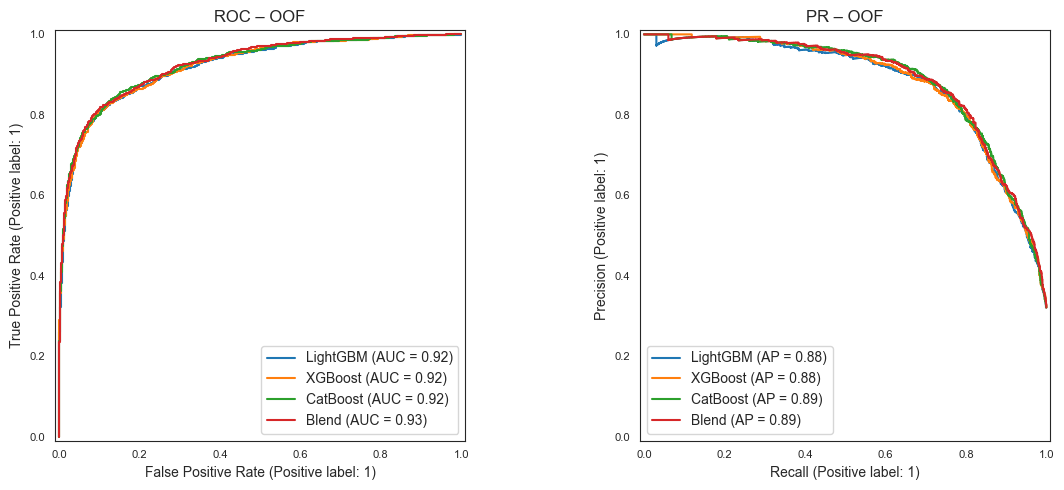

In [48]:
# ------------------------------------------------------------------
# 可视化 – ROC & PR 曲线
# ------------------------------------------------------------------
os.makedirs('figs', exist_ok=True)
save = lambda name: plt.savefig(f'figs/{name}.png', dpi=300, bbox_inches='tight')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ROC
for prob, label in [(oof_lgb, 'LightGBM'), (oof_xgb, 'XGBoost'), (oof_cat, 'CatBoost'), (oof_blend, 'Blend')]:
    RocCurveDisplay.from_predictions(y, prob, name=label, ax=ax[0])
ax[0].set_title('ROC – OOF')

# PR
for prob, label in [(oof_lgb, 'LightGBM'), (oof_xgb, 'XGBoost'), (oof_cat, 'CatBoost'), (oof_blend, 'Blend')]:
    PrecisionRecallDisplay.from_predictions(y, prob, name=label, ax=ax[1])
ax[1].set_title('PR – OOF')

plt.tight_layout()
save('roc_pr')
plt.show()  # 显示图片
plt.close()

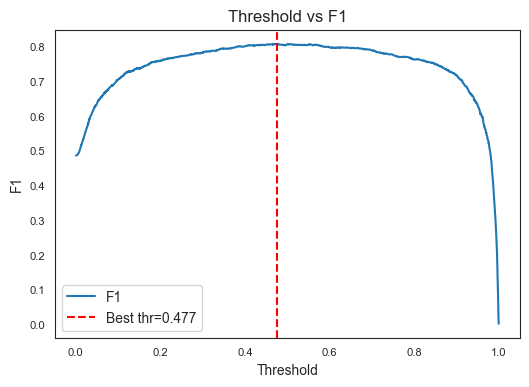

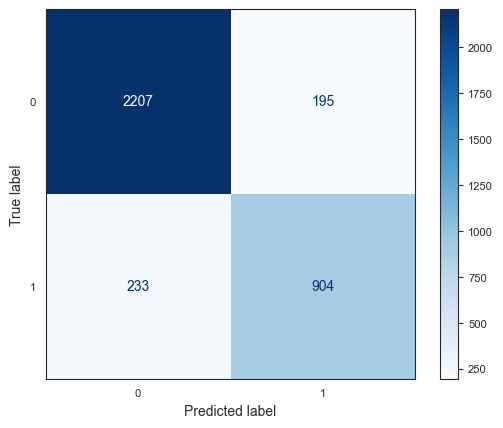

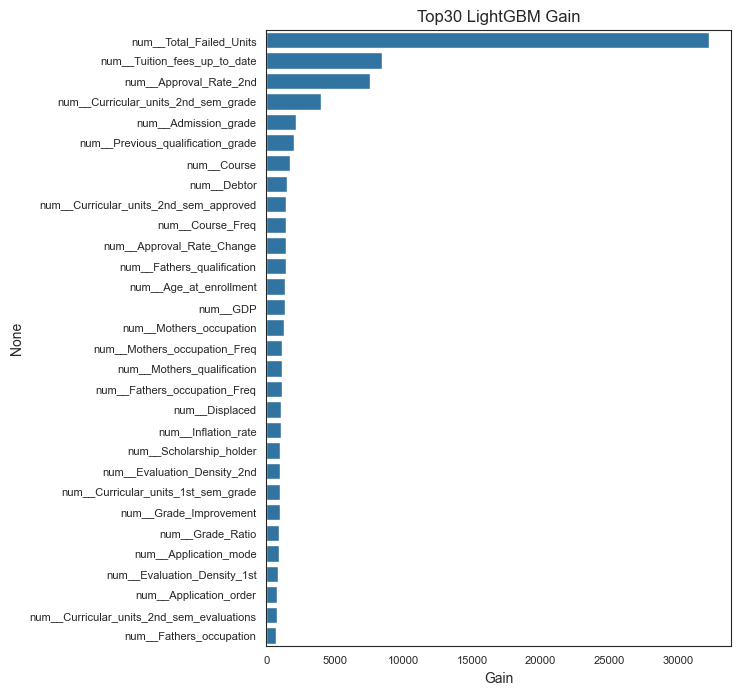

In [49]:
# ========== 阈值选择图（PR曲线 + 最佳阈值） ==========
precision, recall, thresholds = precision_recall_curve(y, oof_blend)
f1s = 2 * (precision * recall) / (precision + recall + 1e-8)
best_thr, best_f1 = thresholds[np.argmax(f1s)], np.max(f1s)

plt.figure(figsize=(6,4))
plt.plot(thresholds, f1s[:-1], label='F1')
plt.axvline(best_thr, color='r', linestyle='--', label=f'Best thr={best_thr:.3f}')
plt.xlabel('Threshold'); plt.ylabel('F1'); plt.title('Threshold vs F1'); plt.legend()
save('threshold_f1')
plt.show()  # 显示图片
plt.close()

# ========== 混淆矩阵 ==========
pred_best = (oof_blend >= best_thr).astype(int)
cm = confusion_matrix(y, pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
save('confusion_matrix')
plt.show()  # 显示图片
plt.close()

# ========== 特征重要性（LightGBM示例） ==========
lgb_booster = m_lgb.booster_ if hasattr(m_lgb, 'booster_') else m_lgb
importance = lgb_booster.feature_importance(importance_type='gain')
feat_names = preprocess.get_feature_names_out()
imp_df = (pd.Series(importance, index=feat_names)
            .sort_values(ascending=False).head(30))
plt.figure(figsize=(6,8))
sns.barplot(x=imp_df.values, y=imp_df.index)
plt.title('Top30 LightGBM Gain'); plt.xlabel('Gain')
save('lgb_importance')
plt.show()  # 显示图片
plt.close()

>>> SHAP 解释性（融合模型代表）


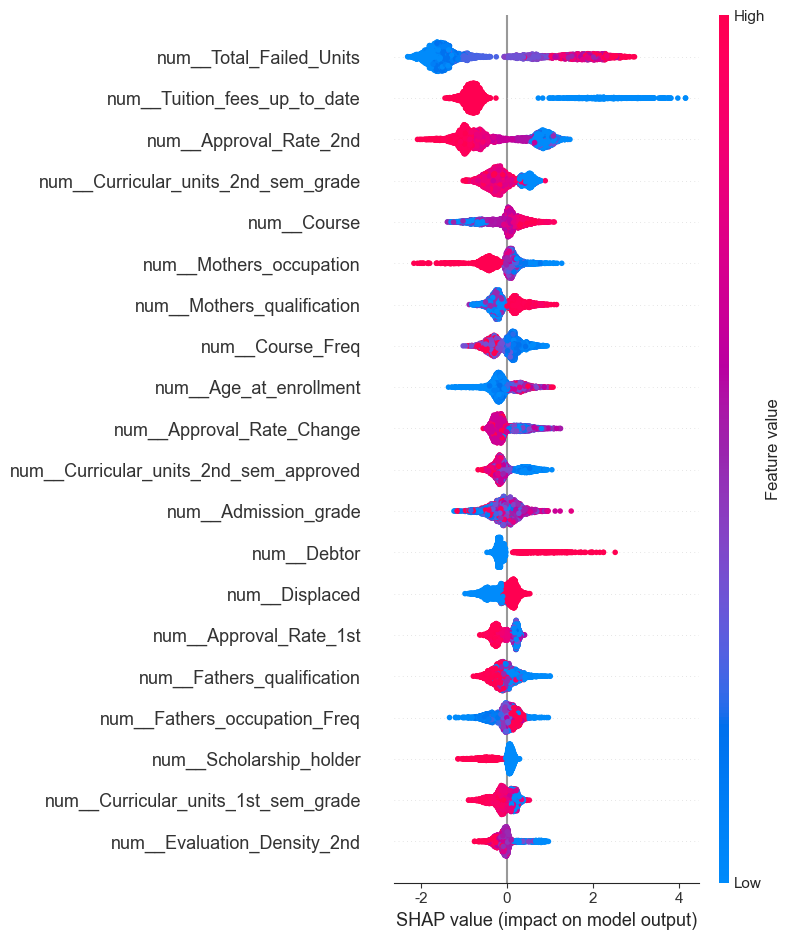

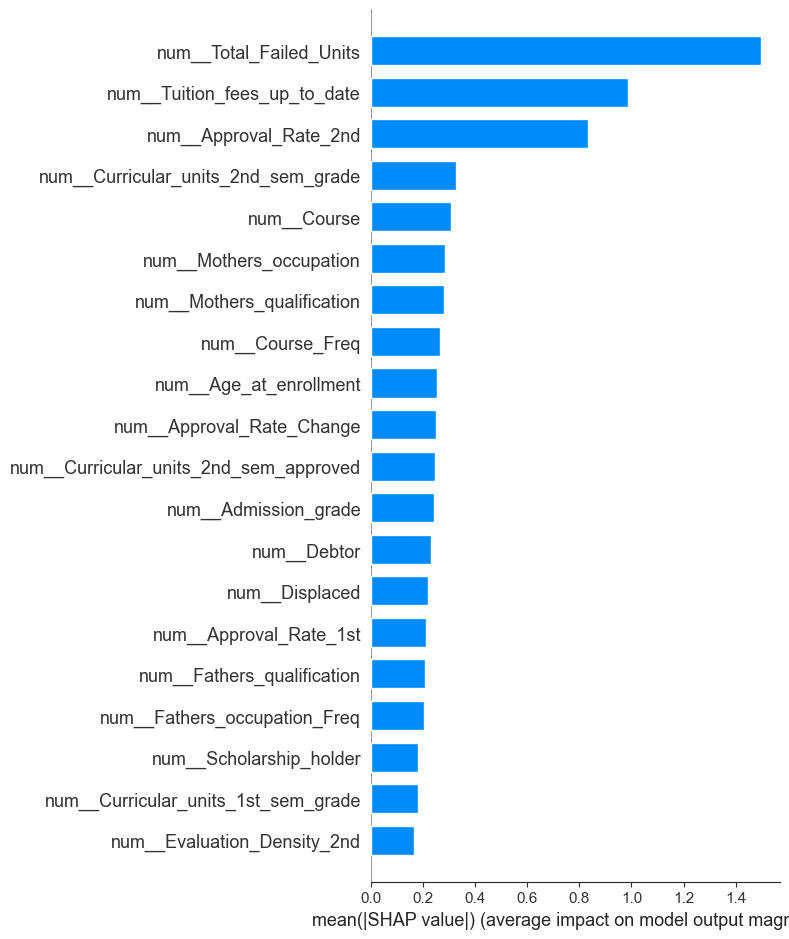

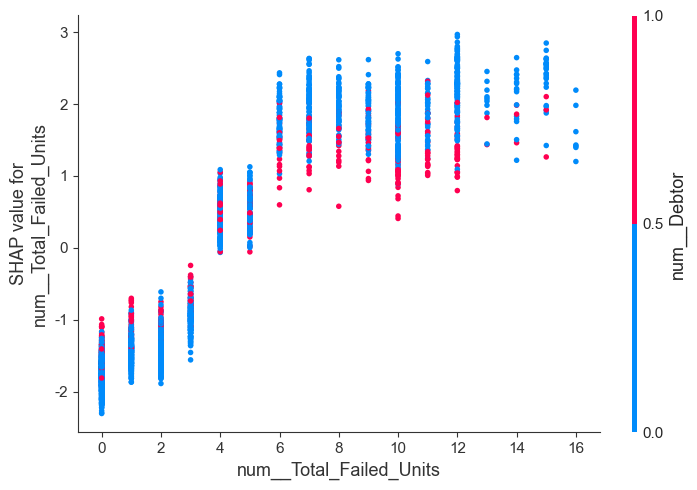

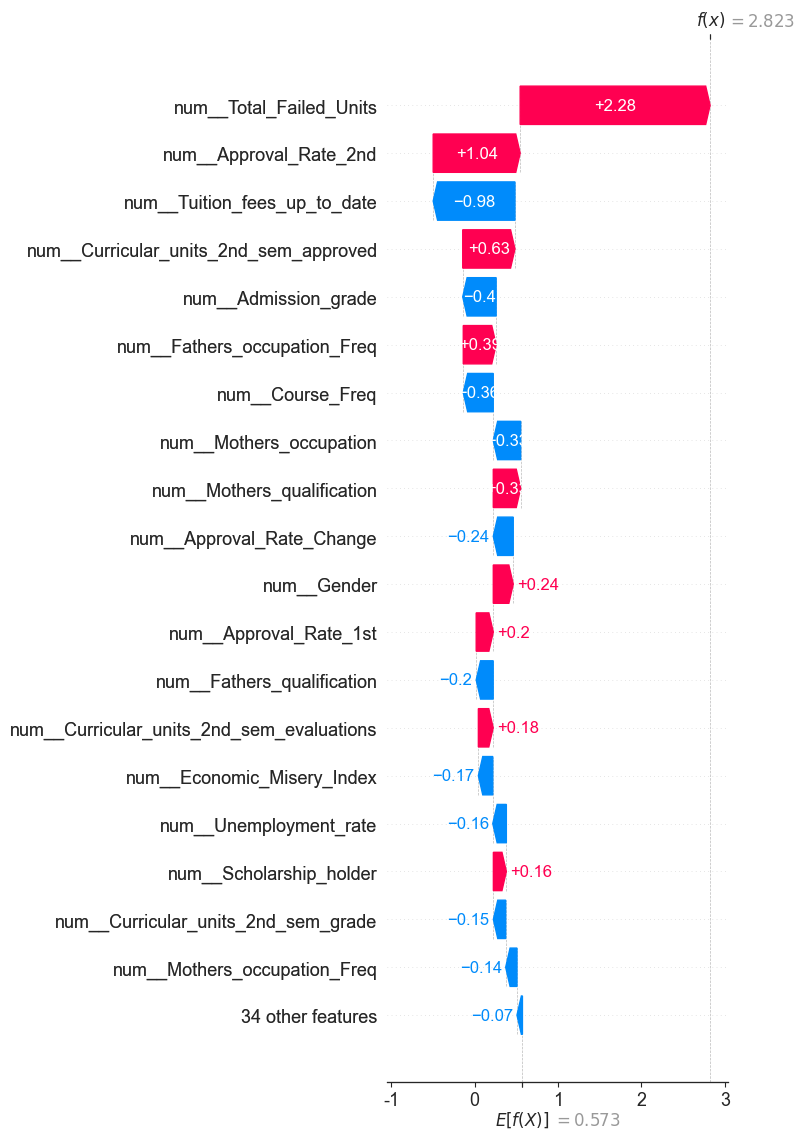

In [50]:
# ------------------------------------------------------------------
# SHAP 汇总（用融合模型代表）
# ------------------------------------------------------------------
print('>>> SHAP 解释性（融合模型代表）')
explainer = shap.TreeExplainer(m_lgb)          # 也可用 m_xgb / m_cat
sample_num = None  # 或者可以取 2k 样本加速
shap_values = explainer.shap_values(X_full[:sample_num])

# 摘要图
shap.summary_plot(shap_values, X_full[:sample_num],
                  feature_names=preprocess.get_feature_names_out(), show=False)
plt.tight_layout()
plt.savefig("figs/shap_summary.png", dpi=300)
save('shap_summary')
plt.show()  # 显示图片
plt.close()

# 条形图
shap.summary_plot(shap_values, X_full[:sample_num],
                  feature_names=preprocess.get_feature_names_out(),
                  plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("figs/shap_bar.png", dpi=300)
save('shap_bar')
plt.show()  # 显示图片
plt.close()

# ====== 2. SHAP 依赖图（以最重要特征为例） ======
top_feat = np.abs(shap_values).mean(0).argmax()  # 最重要特征索引
shap.dependence_plot(top_feat, shap_values, X_full[:sample_num],
                     feature_names=preprocess.get_feature_names_out(), show=False)
plt.tight_layout()
plt.savefig("figs/shap_dependence.png", dpi=300)
save('shap_dependence')
plt.show()  # 显示图片
plt.close()

# ====== 3. SHAP 瀑布图（单样本示例） ======
sample_idx = 0  # 可换任意样本
shap.waterfall_plot(
    shap.Explanation(values=shap_values[sample_idx],
                     base_values=explainer.expected_value,
                     feature_names=preprocess.get_feature_names_out()),
    max_display=20, show=False)
plt.tight_layout()
plt.savefig("figs/shap_waterfall.png", dpi=300)
save('shap_waterfall')
plt.show()  # 显示图片
plt.close()